# Auxetic Materials
*A Jupyter notebook for teaching Poisson's ratio, auxetic materials, and machine learning principles.*

---
## Learning Objectives
By the end, you should be able to:
* Describe and calculate Poisson's ratio.
* Explain how auxetic materials differ from traditional engineering materials and what applications benefit from these properties.
* Use machine learning to predict structures for auxetic material development.

---
## Table of Contents
1. Poisson's Ratio
2. Auxetic Materials
3. Applications of Auxetic Materials
4. Introduction to Using AI for Materials Discovery
5. Activity: Discovering Auxetic Candidates with K-Means Clustering

## 1. Poisson's Ratio
When a material is compressed in one direction, it often bulges out to the sides. When the same material is stretched in tension, it becomes thinner. Poisson's ratio ($\nu$) is the property that describes this behavior of materials.

Experimentally, Poisson's ratio can be calculated by measuring change in lateral and axial dimensions. To do this, extensometers are placed during a tensile test, using procedures which are described in standards such as ASTM E132.

<center>
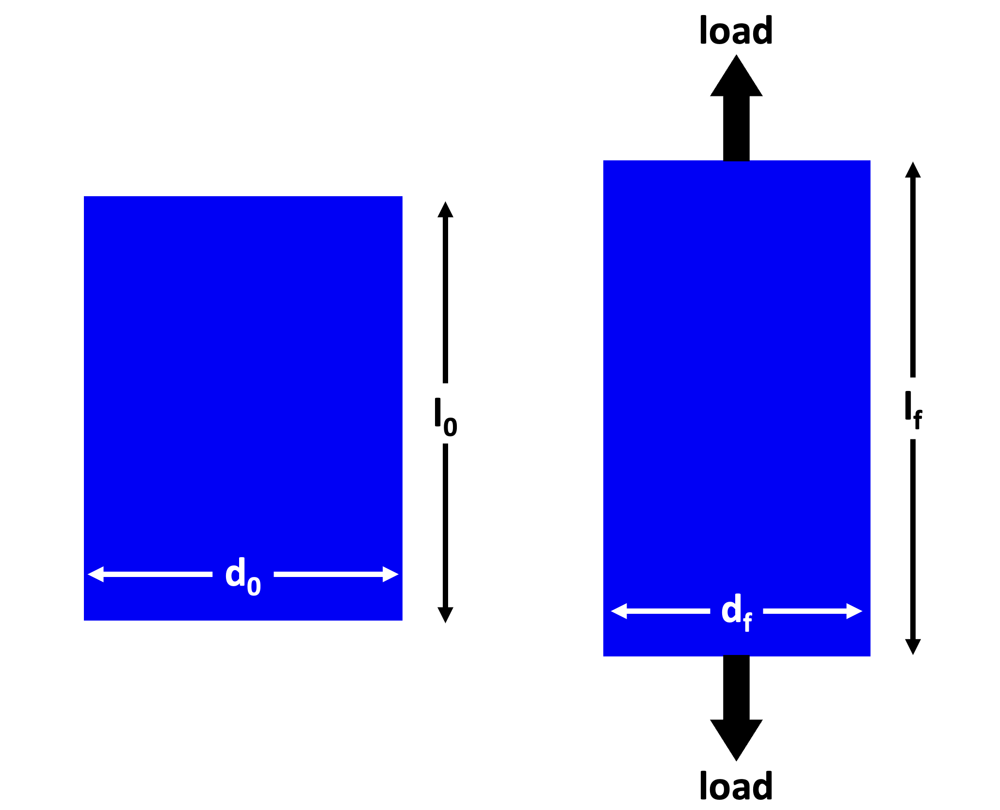
</center>

Extensometers give precise measurements of change in dimensions, which are then used to calculate strain as follows:

$$\epsilon_{lateral} = \frac{d_f - d_0}{d_0}$$
$$\epsilon_{axial} = \frac{l_f - l_0}{l_0}$$

From strain, Poisson's ratio can be defined as the negative ratio of lateral strain (orthogonal to applied force) to axial strain (in the direction of force).

$$\nu = -\frac{\epsilon_{lateral}}{\epsilon_{axial}}$$

Typically, values of Poisson's ratio range from 0 to 0.5.

In the case of $\nu$ = 0, the material is perfectly compressible; for a given axial strain, there is no corresponding lateral strain. In other words, it will not expand to the sides when compressed or shrink when stretched, like **cork**. 

$$\epsilon_{lateral} = 0 \implies \nu = -\frac{0}{\epsilon_{axial}} \boxed{=0}$$

If $\nu$ = 0.5, the material is perfectly incompressible; volumetric strain<span style="color:blue">[*]</span> is zero ($\frac{\Delta V}{V} = 0$). In other words, its volume stays constant when subjected to a load, like **rubber**. The following derivation demonstrates why constant volume results in a Poisson's ratio of 0.5.

$$\frac{\Delta V}{V} = 0 = \epsilon_{lateral (x)} + \epsilon_{lateral (y)} + \epsilon_{axial}$$
$$\nu = -\frac{\epsilon_{lateral}}{\epsilon_{axial}} \implies \epsilon_{lateral} = -{\nu}{\epsilon_{axial}}$$
$$0 = -{\nu}{\epsilon_{axial}} - {\nu}{\epsilon_{axial}} + \epsilon_{axial}$$
$$0 = (-2{\nu} + 1)\epsilon_{axial}$$
$$0 = -2{\nu} + 1$$
$$\boxed{\nu = 0.5}$$

<span style="font-size:small;"><span style="color:blue">[*]</span> Volumetric strain is the sum of the linear strains in the three dimensions.</span>

The animation below visualizes the behavior of materials on these extreme ends of Poisson's ratio.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

### 1. SETUP
# Starting dimensions for rectangles and Poisson's ratio
width_0 = 3.0
len_0 = 5.0
nu1 = 0.0
nu2 = 0.5

### 2. CALCULATIONS
# Calculate vertices with changing stretch values
def get_vertices(strain, nu):
    # Lateral compression
    current_len = len_0 * strain
    # Vertical stretch
    current_width = width_0 * (1 - nu * (strain - 1))
    x = [-current_width/2, current_width/2, current_width/2, -current_width/2, -current_width/2]
    y = [current_len/2, current_len/2, -current_len/2, -current_len/2, current_len/2]
    return x, y

# Define function to sync rectangle stretch and compression
def animate(t):
    # Set limits on how far rectangle will stretch over cycle
    strain = 1.0 + 0.3 * np.sin(2 * np.pi * t / 100)
    
    # Update left
    x1, y1 = get_vertices(strain, nu1)
    line1.set_data(x1, y1)
    fill1.set_xy(np.array([x1, y1]).T)
    
    # Update right
    x2, y2 = get_vertices(strain, nu2)
    line2.set_data(x2, y2)
    fill2.set_xy(np.array([x2, y2]).T)
    
    return line1, fill1, line2, fill2

### 3. PLOT
# Create side-by-side subplots with same axes for comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
for ax, nu in zip([ax1, ax2], [nu1, nu2]):
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True)
    ax.set_title(f'\nu = {nu}')

# Set up left plot (nu1)
x1, y1 = get_vertices(1.0, nu1)
line1, = ax1.plot(x1, y1, 'b-', lw=3)
fill1 = ax1.fill(x1, y1, 'b', alpha=0.3)[0]

# Set up right plot (nu2)
x2, y2 = get_vertices(1.0, nu2)
line2, = ax2.plot(x2, y2, 'r-', lw=3)
fill2 = ax2.fill(x2, y2, 'r', alpha=0.3)[0]

### 4. ANIMATION
ani = FuncAnimation(fig, animate, frames=100, interval=50, blit=True)
plt.close()

HTML(ani.to_html5_video())

While 0 and 0.5 are traditionally delineate the extreme ends of Poisson's ratio, most materials fall somewhere in the middle. The following table includes the Poisson's ratio of several example materials.

| Material | Poisson's Ratio ($\nu$) [1]  |
| --- | --- |
| Silicate glasses | 0.20–0.28 | 
| Aluminum oxide | 0.23 |
| Low alloy steel | 0.29–0.30 |
| Aluminum 6061-T6 | 0.33 |
| Polyvinyl chloride| 0.38 |
| Polycarbonate | 0.42 |
| Gold | 0.45 |
| Natural rubber | 0.50 |

## 2. Auxetic Materials
Contrary to the intuition established above, auxetic materials defy this pattern. When compressed in one direction, the cross-section also contracts, and when stretched in tension, the cross-section expands laterally. This leads to a **negative Poisson's ratio**.

The following animation demonstrates two materials: one with a typical Poisson's ratio, and the other with the negative of that same value. Compare the change in shape of these two materials as they are subjected to tensile and compressive loads.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

### 1. SETUP
# Starting dimensions for rectangles and Poisson's ratio
width_0 = 3.0
len_0 = 5.0
nu1 = 0.3     # Potentially make this a slider for students to change
nu2 = -nu1

### 2. CALCULATIONS
# Calculate vertices with changing stretch values
def get_vertices(strain, nu):
    # Lateral compression
    current_len = len_0 * strain
    # Vertical stretch
    current_width = width_0 * (1 - nu * (strain - 1))
    x = [-current_width/2, current_width/2, current_width/2, -current_width/2, -current_width/2]
    y = [current_len/2, current_len/2, -current_len/2, -current_len/2, current_len/2]
    return x, y

# Define function to sync rectangle stretch and compression
def animate(t):
    # Set limits on how far rectangle will stretch over cycle
    strain = 1.0 + 0.3 * np.sin(2 * np.pi * t / 100)
    
    # Update left
    x1, y1 = get_vertices(strain, nu1)
    line1.set_data(x1, y1)
    fill1.set_xy(np.array([x1, y1]).T)
    
    # Update right
    x2, y2 = get_vertices(strain, nu2)
    line2.set_data(x2, y2)
    fill2.set_xy(np.array([x2, y2]).T)
    
    return line1, fill1, line2, fill2

### 3. PLOT
# Create side-by-side subplots with same axes for comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
for ax, nu in zip([ax1, ax2], [nu1, nu2]):
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.grid(True)

# Set up left plot (nu1)
x1, y1 = get_vertices(1.0, nu1)
line1, = ax1.plot(x1, y1, 'r-', lw=3)
fill1 = ax1.fill(x1, y1, 'r', alpha=0.3)[0]
ax1.set_title(f'Typical Material \nu = {nu1}')


# Set up right plot (nu2)
x2, y2 = get_vertices(1.0, nu2)
line2, = ax2.plot(x2, y2, 'g-', lw=3)
fill2 = ax2.fill(x2, y2, 'g', alpha=0.3)[0]
ax2.set_title(f'Auxetic Material \nu = {nu2}')

### 4. ANIMATION
ani = FuncAnimation(fig, animate, frames=100, interval=50, blit=True)
plt.close()

HTML(ani.to_html5_video())

On their own, materials do not exhibit auxetic behavior. Rather, this behavior must be enabled by shaping the material into specific geometric architectures. These geometric architectures enable coordinated movement of smaller unit cells within the material. As one unit cell moves, rotates, or changes shape, it pulls on its neighbors, transferring loads in complex ways.

Several metamaterial designs that have been engineered for auxetic behavior are shown below.

<center>
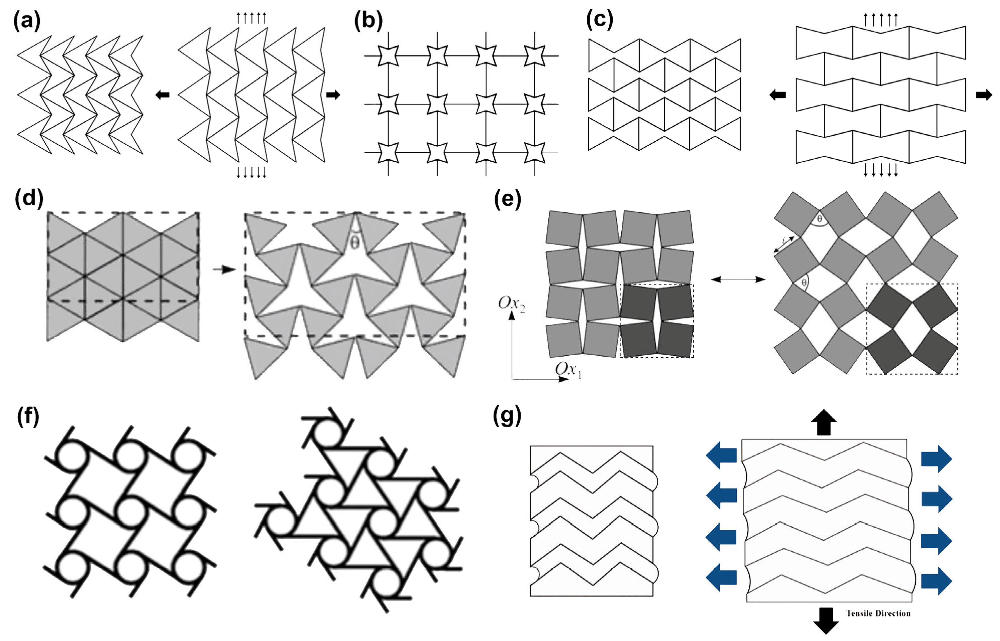
</center>
<figcaption align="center"><b>Figure 1:</b> Several structures that have exhibited auxetic behavior: (a) re-entrant triangular structure, (b) re-entrant star structure, (c) re-entrant hexagonal structure, (d) rotating triangle, (e) rotating square, (f) chiral structure (Copyright 2010, Academic Journals), (g) foldable structure (Copyright 2019, SAGE Publications Ltd.) [2].</figcaption>

<p></p>

The unique structures of auxetic materials yield advantageous physical properties, including **low density**, **improved fatigue resistance**, **synclastic (uniform) curvature** under bending loads, and **enhanced energy absorption and dissipation** [3]. 

However, due to their structures, auxetic materials often exhibit **low stiffness and stability**, while also suffering from an **increased tendency to buckle and high anisotropy** [3].

Engineers can leverage the advantages and disadvantages of auxetic materials to achieve a desired performance.

## 3. Applications of Auxetic Materials
The properties of auxetic materials have led to their use across several industries and in a multitude of functions. 

### Sportswear and Protective Equipment
Low density and impact resistance are important properties when considering materials for wearable items, especially in sports. For those reasons, the use of auxetic designs has gained popularity in applications such as running shoes and helmets, where they limit the forces on the wearer's body, reduce risk of injury, and improve safety.

<center>
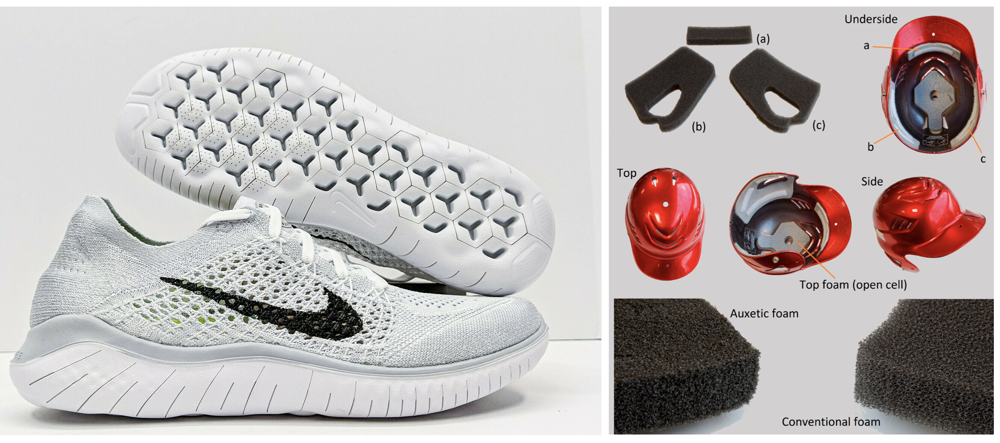
</center>
<figcaption align="center"><b>Figure 2:</b> left: Nike Women's Free RN Flyknit 2018 Running Shoes [4], right: ongoing research by Sheffield Hallam University on auxetic materials for baseball helmets [5].</figcaption>

### Biomedicine
The tissues and organs of the human body experience complex loading, some of which cannot be replicated by traditional abiotic materials. Auxetic materials offer one way to expand the available design space for biomedical devices by opening up previously inaccessible combinations of material properties. For example, auxetic structures that mimic tissue biomechanics and react dynamically to bodily movement are being explored as scaffolds for wound healing and tissue engineering [6]. This ongoing research shows potential for auxetic materials to be used in devices from stents to artificial organs to prostheses.

<center>
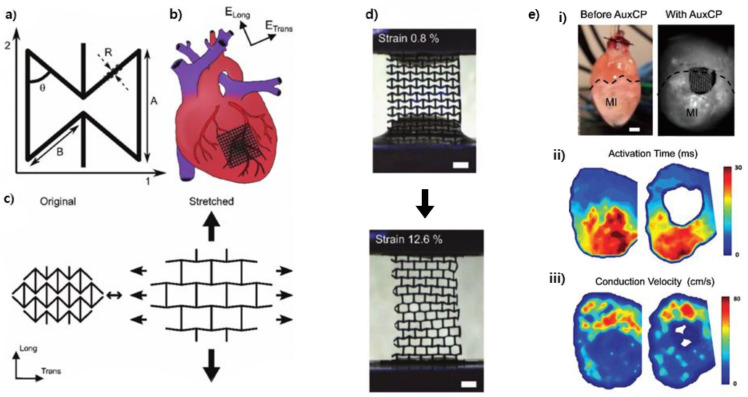
</center>
<figcaption align="center"><b>Figure 3:</b> Research on an auxetic patch to treat myocardial infarction (heart attack) [6].</figcaption>

### Aerospace, Automotive, and Defense
The energy absorption and dissipation capabilities of auxetic materials make them attractive in industries that require vibration control. Aircraft, consumer vehicles, and armored military vehicles all require vibration and shock absorbers to function as intended. Smaller components, too, such as sensors and actuators can take advantage of the unique ways auxetic materials change under loading [6]. Even in applications as widespread as screws, auxetic materials are being explored for their combination of compressive strength, shear stiffness, and elastic modulus [3,6]

<center>
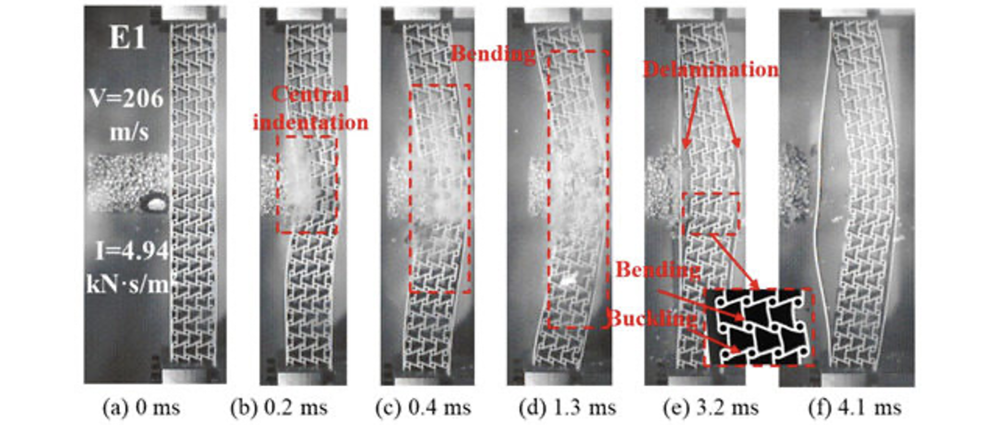
</center>
<figcaption align="center"><b>Figure 4:</b> Test on the ability of an auxetic material to resist a ballistic projectile [7].</figcaption>



## 4. Introduction to Using AI for Materials Discovery
Artificial intelligence and machine learning (AI/ML) offers a versatile toolbox for sorting through large quantities of data. In general, AI/ML methods can be described as **supervised learning** or **unsupervised learning**.

In **supervised learning**, the operator labels training data with known inputs and outputs. The machine then learns the relationships between inputs and outputs, and is therefore able to make predictions about new data [8]. In a simple example, when given a list of densities and their corresponding material class (e.g. metals, ceramics, polymers), a machine can learn that polymers generally have low density, and it can classify new data based on that rule of thumb.

In **unsupervised learning**, the operator does give the machine a definite list of corresponding inputs and outputs, but asks the machine to group the data into the clusters it thinks best fit underlying patterns [8]. In other words, the operator does not give the machine an "answer key" to which items fit in which categories, or even what categories exist or how many there are. This approach can allow the machine to more freely discover associations that may not be obvious to the operator. Returning to the density and material class example, an unsupervised algorithm may discover that the data best fits into three categories that map onto metals, ceramics, and polymers, or it may discover that the data better fits into four categories that map onto light metals, heavy metals, ceramics, polymers.

This activity will focus on a form of **unsupervised learning** known as **k-means clustering**.

In k-means clustering, an algorithm attempts to find ways to group data into discrete clusters that contain all members of a group and no extraneous members. In other words:

1. Data points within a cluster should be similar to one another (minimal intracluster difference).
2. Clusters should be distinct from each other (maximal intercluster difference).

To accomplish this, the algorithm partitions the data into groups, then iteratively redraws cluster boundaries to better match the two criteria listed above. Over many iterations, the model stabilizes around a categorization that it calculates has the best combination of specific and distinct clusters.

### Pre-Activity
The capabilities of AI/ML can be leveraged to determine which materials, or even hypothetical substances, have potential in auxetic designs. **However, understanding the materials science behind the problem is critical before handing the data over to a computer.**

Although the macroscale design of the material is ultimately what produces auxetic behavior, the base material is also an important consideration [3], and in order for a computer to produce usable results, the operator must provide relevant data. Taken together, this means it is up to the engineer to curate the materials property data that is fed into the model.

Some important properties for creating auxetic structures include:
1. **Elastic Modulus:** Since auxetic behavior relies on the coordinated movement of unit cells within the metamaterial, the base material should have a low modulus of elasticity; that is, it should be compliant enough to deform elastically under a load [6].
2. **Fatigue Resistance:** Many applications of auxetics require repeated deformation, so the material should retain its integrity even after many cycles of loading [3,5,6].
3. **Toughness:** One of the strengths of auxetic designs is their ability to absorb energy; in order to accomplish this, the base material must also be able to absorb a fair amount of energy without brittle fracture [3].

With this knowledge and data collected from Granta, we will walk through one example of using AI/ML to find candidates for auxetic materials.

## 5. Activity: Discovering Auxetic Candidates with K-Means Clustering

**Dataset:** Ansys Granta EduPack export — 100 materials, 7 mechanical properties (`Materials_and_Selected_Properties.csv`)

**Goal:** Use unsupervised machine learning to group materials by property profile and identify
candidates whose properties make them compatible with auxetic geometric architectures.

---
> **Reminder:** auxetic behavior (ν < 0) arises from geometric architecture (honeycombs,
> rotating rigid units, chiral lattices), not from bulk material properties alone), so we cannot directly read
> auxetic potential off of a properties table. What we *can* do is find which material families have the
> right combination of low density, low stiffness, and cellular/deformable structure to *host* those
> architectures.


#### Setup

In [1]:
# Standard scientific Python stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# Nicer default plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print("Libraries loaded ✓")


Libraries loaded ✓


#### Load the Dataset

We work directly with the provided CSV.

In [2]:
df = pd.read_csv("Materials_and_Selected_Properties.csv")
print(f"Dataset shape: {df.shape[0]} materials × {df.shape[1]-1} properties")


Dataset shape: 100 materials × 7 properties


In [3]:
# Quick look at the data
df.head(8)


,Material Name,Density (g/cm^3),Elastic Modulus (GPa),Yield Stress (MPa),Poisson's Ratio,Fatigue Strength 10^7 cycles (MPa),Fracture Toughness (Mpa*m^.5),Toughness (kJ/m^2)
0,Acroyonitrile Butadiene Styrene (Extrusion),1.050,2.45,37.35,0.408,16.0,2.00,1.70000
1,Acroyonitrile Butadiene Styrene Foam,0.840,1.25,22.00,0.275,13.2,0.45,1.65000
2,Aerated Concrete,0.650,15.00,0.85,0.185,0.7,0.05,0.00017
3,Aluminum Foam,0.500,5.00,7.50,0.290,7.5,2.05,0.85000
4,Aluminum 413.0,2.655,70.40,145.00,0.330,108.5,22.80,7.90000
5,Aluminum 705.0,2.790,70.80,127.00,0.330,65.2,31.25,13.90000
6,Aluminum,2.710,70.50,165.00,0.330,72.5,33.50,16.00000
7,Aluminum-polyethylene Composite,23.900,18.50,60.00,0.426,35.0,32.50,57.75000


In [4]:
# Summary statistics — check the ranges look physically reasonable
df.describe().round(3)


,Density (g/cm^3),Elastic Modulus (GPa),Yield Stress (MPa),Poisson's Ratio,Fatigue Strength 10^7 cycles (MPa),Fracture Toughness (Mpa*m^.5),Toughness (kJ/m^2)
count,100.000,100.000,100.000,100.000,96.000,95.000,95.000
mean,5.264,106.646,366.848,0.310,171.581,37.821,40.593
std,4.751,116.815,525.899,0.076,191.352,54.062,171.702
min,0.020,0.002,0.135,0.150,0.080,0.002,0.000
25%,1.306,4.214,32.938,0.268,17.188,1.277,0.157
50%,3.305,71.750,106.250,0.290,68.850,23.650,4.960
75%,8.020,200.750,425.625,0.348,315.750,59.825,24.975
max,23.900,669.000,2865.000,0.500,690.000,299.500,1640.000


In [5]:
# Missing value count per property
print("Missing values per column:")
print(df.isnull().sum().to_string())


Missing values per column:
Material Name                         0
Density (g/cm^3)                      0
Elastic Modulus (GPa)                 0
Yield Stress (MPa)                    0
Poisson's Ratio                       0
Fatigue Strength 10^7 cycles (MPa)    4
Fracture Toughness (Mpa*m^.5)         5
Toughness (kJ/m^2)                    5


#### Feature Scaling — Getting the Units Right for ML

This is one of the most important steps and the one students most often skip.

K-means clustering works by minimizing **Euclidean distance** between data points, which is essentially applying the Pythagorean theorem to higher dimensions.
This means that if one feature ranges from 0.001 to 700 and another ranges from 0.15 to 0.50,
the first feature will completely dominate the distance calculation, and the algorithm
will effectively ignore the second feature.

We have two separate problems here:

1. **Span problem:** Density and Elastic Modulus each span several orders of magnitude.
   A StandardScaler cannot fix this on its own; it just shifts and rescales a wide
   distribution into a still-wide z-score distribution. We need a **log-transform**
   first to compress the tails.

2. **Units problem:** After log-transforming, the remaining features still have
   different units and standard deviations. A **StandardScaler** (zero mean,
   unit variance) puts everyone on equal footing.


The following code will help mitigate these problems by normalizing the data.

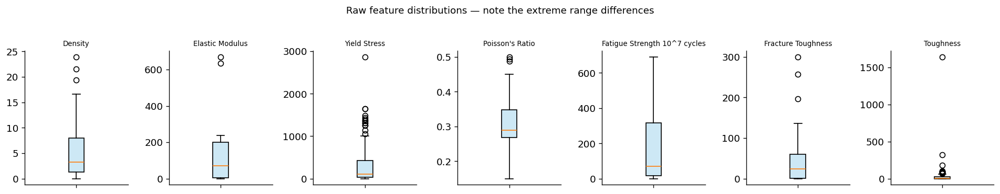


Raw feature ranges:
  Density (g/cm^3)                               min=0.02,  max=23.9,  ratio=1195.0×
  Elastic Modulus (GPa)                          min=0.0015,  max=669,  ratio=446000.0×
  Yield Stress (MPa)                             min=0.135,  max=2865,  ratio=21222.2×
  Poisson's Ratio                                min=0.15,  max=0.5,  ratio=3.3×
  Fatigue Strength 10^7 cycles (MPa)             min=0.08,  max=690,  ratio=8625.0×
  Fracture Toughness (Mpa*m^.5)                  min=0.0025,  max=299.5,  ratio=119800.0×
  Toughness (kJ/m^2)                             min=0.00017,  max=1640,  ratio=9647058.8×


In [6]:
# ── Visualize the raw dynamic range problem ────────────────────────

FEATURE_COLS = [
    "Density (g/cm^3)",
    "Elastic Modulus (GPa)",
    "Yield Stress (MPa)",
    "Poisson's Ratio",
    "Fatigue Strength 10^7 cycles (MPa)",
    "Fracture Toughness (Mpa*m^.5)",
    "Toughness (kJ/m^2)",
]

X_raw = df[FEATURE_COLS].copy()

fig, axes = plt.subplots(1, len(FEATURE_COLS), figsize=(16, 3))
for ax, col in zip(axes, FEATURE_COLS):
    ax.boxplot(X_raw[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="#cde8f5"))
    ax.set_title(col.split("(")[0].strip(), fontsize=8, wrap=True)
    ax.set_xticklabels([])

fig.suptitle("Raw feature distributions — note the extreme range differences", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("\nRaw feature ranges:")
for col in FEATURE_COLS:
    vals = X_raw[col].dropna()
    print(f"  {col:<45}  min={vals.min():.4g},  max={vals.max():.4g},  ratio={vals.max()/vals.min():.1f}×")


In [7]:
# ── Log-transform the wide-range features ───────────────────────────
#
# We use log10 because the values are already in physical units that span decades.
# log10 is easier to interpret: log10(1000) = 3 means "three orders of magnitude".
#
# ONLY log-transform features that span multiple decades.
# Poisson's ratio (0.15–0.50) does NOT need it.

LOG_COLS = ["Density (g/cm^3)", "Elastic Modulus (GPa)"]

X_log = X_raw.copy()
for col in LOG_COLS:
    X_log[col] = np.log10(X_log[col])
    print(f"Log-transformed: {col}")

print("\nAfter log-transform — ranges are now much more comparable:")
for col in FEATURE_COLS:
    vals = X_log[col].dropna()
    print(f"  {col:<45}  min={vals.min():.3f},  max={vals.max():.3f}")


Log-transformed: Density (g/cm^3)
Log-transformed: Elastic Modulus (GPa)

After log-transform — ranges are now much more comparable:
  Density (g/cm^3)                               min=-1.699,  max=1.378
  Elastic Modulus (GPa)                          min=-2.824,  max=2.825
  Yield Stress (MPa)                             min=0.135,  max=2865.000
  Poisson's Ratio                                min=0.150,  max=0.500
  Fatigue Strength 10^7 cycles (MPa)             min=0.080,  max=690.000
  Fracture Toughness (Mpa*m^.5)                  min=0.003,  max=299.500
  Toughness (kJ/m^2)                             min=0.000,  max=1640.000


In [8]:
# ── Handle missing values ────────────────────────────────────────
#
# SimpleImputer replaces NaN with the column mean.
# For a small dataset like this (100 rows, a handful missing per column),
# mean imputation is a reasonable choice.
# In a research setting you would want to discuss this choice carefully.

imputer = SimpleImputer(strategy="mean")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_log),
    columns=FEATURE_COLS
)
print(f"Missing values remaining after imputation: {X_imputed.isnull().sum().sum()}")


Missing values remaining after imputation: 0


In [9]:
# ── StandardScaler — zero mean, unit variance ───────────────────────
#
# After log-transforming, we still have different units and scales.
# StandardScaler gives every feature a mean of 0 and std of 1,
# so no single feature dominates the Euclidean distance calculation.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS)

print("After StandardScaler — means and standard deviations:")
print(X_scaled.describe().loc[["mean", "std"]].round(4))


After StandardScaler — means and standard deviations:
      Density (g/cm^3)  Elastic Modulus (GPa)  Yield Stress (MPa)  \
mean             0.000                  0.000               0.000   
std              1.005                  1.005               1.005   

      Poisson's Ratio  Fatigue Strength 10^7 cycles (MPa)  \
mean            0.000                               0.000   
std             1.005                               1.005   

      Fracture Toughness (Mpa*m^.5)  Toughness (kJ/m^2)  
mean                          0.000              -0.000  
std                           1.005               1.005  


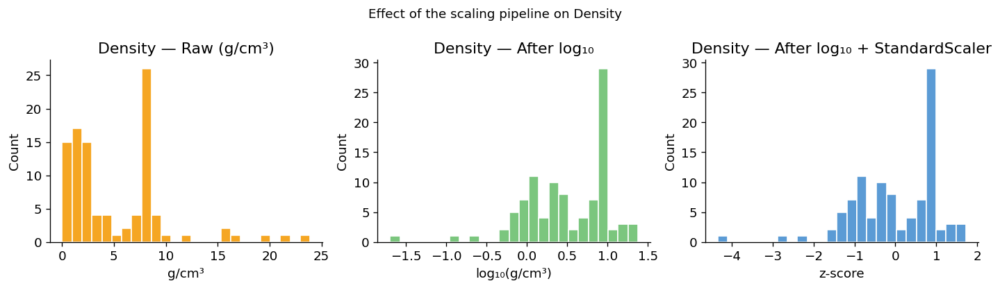

In [10]:
# ── Side-by-side comparison for Density ───────────────────────

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

axes[0].hist(X_raw["Density (g/cm^3)"], bins=25, color="#f5a623", edgecolor="white")
axes[0].set_title("Density — Raw (g/cm³)")
axes[0].set_xlabel("g/cm³")

axes[1].hist(X_log["Density (g/cm^3)"], bins=25, color="#7bc67e", edgecolor="white")
axes[1].set_title("Density — After log₁₀")
axes[1].set_xlabel("log₁₀(g/cm³)")

axes[2].hist(X_scaled["Density (g/cm^3)"], bins=25, color="#5b9bd5", edgecolor="white")
axes[2].set_title("Density — After log₁₀ + StandardScaler")
axes[2].set_xlabel("z-score")

for ax in axes:
    ax.set_ylabel("Count")

plt.suptitle("Effect of the scaling pipeline on Density", fontsize=11)
plt.tight_layout()
plt.show()


#### Finding the Right Number of Clusters (k)

The next step is to determine the number of clusters, k, that best describes the data. To choose k, we use two diagnostic tools:

- **Elbow curve** (Inertia / Within-Cluster Sum of Squares): Inertia always decreases
  as k increases. Look for the "elbow" — the point where adding another cluster
  gives diminishing returns.

- **Silhouette score**: Measures how well each point fits its own cluster vs.
  neighboring clusters. Ranges from −1 to +1; higher is better. Unlike inertia,
  this has a defined optimum.

> There is rarely a single "correct" k. Use these tools to identify
> a reasonable range, then use your judgement as an engineer to decide which k displays the data the most faithfully.

In [11]:
# ── Run K-means for k = 2 through 8 ──────────────────────────────

K_RANGE = range(2, 9)
inertias   = []
silhouettes = []

# Add these two lines to fix "Could not find the number of physical cores" error
import os
os.environ['OMP_NUM_THREADS'] = '1'

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    print(f"  k={k}  inertia={km.inertia_:.1f}  silhouette={silhouette_score(X_scaled, labels):.3f}")


  k=2  inertia=455.3  silhouette=0.370
  k=3  inertia=344.2  silhouette=0.379
  k=4  inertia=273.6  silhouette=0.353
  k=5  inertia=213.6  silhouette=0.360
  k=6  inertia=178.8  silhouette=0.389
  k=7  inertia=150.5  silhouette=0.377
  k=8  inertia=127.5  silhouette=0.418


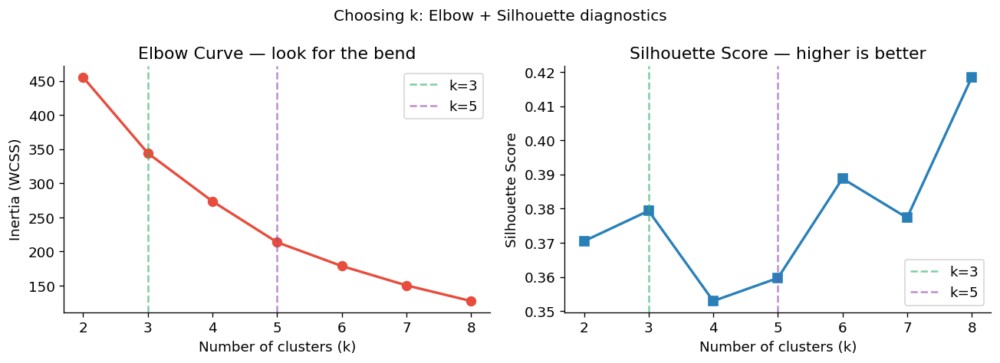

In [12]:
# ── Plot the two diagnostics side-by-side ───────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Elbow curve
ax1.plot(list(K_RANGE), inertias, "o-", color="#e74c3c", linewidth=2, markersize=7)
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia (WCSS)")
ax1.set_title("Elbow Curve — look for the bend")
ax1.set_xticks(list(K_RANGE))

# Silhouette
ax2.plot(list(K_RANGE), silhouettes, "s-", color="#2980b9", linewidth=2, markersize=7)
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score — higher is better")
ax2.set_xticks(list(K_RANGE))

# Highlight k=3 and k=5
for ax in (ax1, ax2):
    ax.axvline(3, color="#27ae60", linestyle="--", alpha=0.6, label="k=3")
    ax.axvline(5, color="#8e44ad", linestyle="--", alpha=0.6, label="k=5")
    ax.legend()

plt.suptitle("Choosing k: Elbow + Silhouette diagnostics", fontsize=12)
plt.tight_layout()
plt.show()


#### Fit K-Means: Comparing k = 3 vs. k = 5

We fit both models and store the cluster labels.
Changing k is a single parameter change, but the rest of the pipeline is identical.

In [13]:
# ── Fit both models ───────────────────────────────────────

km3 = KMeans(n_clusters=3, random_state=42, n_init=20)
km5 = KMeans(n_clusters=5, random_state=42, n_init=20)

df["Cluster_k3"] = km3.fit_predict(X_scaled)
df["Cluster_k5"] = km5.fit_predict(X_scaled)

print(f"k=3  |  inertia={km3.inertia_:.1f}  |  silhouette={silhouette_score(X_scaled, df['Cluster_k3']):.3f}")
print(f"k=5  |  inertia={km5.inertia_:.1f}  |  silhouette={silhouette_score(X_scaled, df['Cluster_k5']):.3f}")


k=3  |  inertia=344.2  |  silhouette=0.379
k=5  |  inertia=213.6  |  silhouette=0.360


In [14]:
# ── Materials per cluster ────────────────────────────────────

print("=== k=3: Materials per cluster ===")
print(df["Cluster_k3"].value_counts().sort_index().rename("n_materials").to_string())
print()
print("=== k=5: Materials per cluster ===")
print(df["Cluster_k5"].value_counts().sort_index().rename("n_materials").to_string())


=== k=3: Materials per cluster ===
Cluster_k3
0    47
1     1
2    52

=== k=5: Materials per cluster ===
Cluster_k5
0    23
1    22
2    28
3    26
4     1


#### Results Tables

Two types of results table are useful here:

1. **Cluster assignment table:** which material went to which cluster?
2. **Cluster profile table:** what are the average properties of each cluster?
   This is how you interpret *what* the clusters mean.

In [15]:
# ── Table 1a: Full assignment table for k=3 (sorted by cluster) ──────────────

DISPLAY_COLS = [
    "Material Name",
    "Density (g/cm^3)",
    "Elastic Modulus (GPa)",
    "Poisson's Ratio",
    "Cluster_k3",
]

results_k3 = (df[DISPLAY_COLS]
              .sort_values(["Cluster_k3", "Material Name"])
              .reset_index(drop=True))

results_k3["Cluster_k3"] = results_k3["Cluster_k3"].apply(lambda x: f"Cluster {x}")
results_k3


,Material Name,Density (g/cm^3),Elastic Modulus (GPa),Poisson's Ratio,Cluster_k3
0,Aluminum-polyethylene Composite,23.9000,18.500,0.426,Cluster 0
1,Brass C26000,8.5000,105.000,0.345,Cluster 0
2,Brass C85400,8.2000,97.000,0.345,Cluster 0
3,"Bronze C50900, half-hard",8.8400,120.000,0.345,Cluster 0
4,"Bronze C50900, hard",8.8400,120.000,0.345,Cluster 0
...,...,...,...,...,...
95,Silicon,2.3300,160.000,0.270,Cluster 2
96,Soda-lime Glass 0070,2.4950,70.000,0.215,Cluster 2
97,Soda-lime Glass 0080,2.4750,69.950,0.215,Cluster 2
98,Styrene Butadiene Rubber,0.9505,0.006,0.488,Cluster 2


In [16]:
# ── Table 1b: Full assignment table for k=5 ───────────────────────────

DISPLAY_COLS_5 = [
    "Material Name",
    "Density (g/cm^3)",
    "Elastic Modulus (GPa)",
    "Poisson's Ratio",
    "Cluster_k5",
]

results_k5 = (df[DISPLAY_COLS_5]
              .sort_values(["Cluster_k5", "Material Name"])
              .reset_index(drop=True))

results_k5["Cluster_k5"] = results_k5["Cluster_k5"].apply(lambda x: f"Cluster {x}")
results_k5


,Material Name,Density (g/cm^3),Elastic Modulus (GPa),Poisson's Ratio,Cluster_k5
0,Diamond,3.510,113.00,0.200,Cluster 0
1,Inconel 718 (Solution Treated and Aged),8.220,203.00,0.296,Cluster 0
2,Inconel 718 (Solution Treated),8.220,208.00,0.296,Cluster 0
3,Nickel-tungsten MAR-M 200,8.525,220.00,0.285,Cluster 0
4,"Stainless Steel, martensitic, ASTM CA-15",7.610,200.00,0.280,Cluster 0
...,...,...,...,...,...
95,"Plywood, 5 ply, perpendicular to face layer",0.750,4.25,0.250,Cluster 3
96,Silicon,2.330,160.00,0.270,Cluster 3
97,Soda-lime Glass 0070,2.495,70.00,0.215,Cluster 3
98,Soda-lime Glass 0080,2.475,69.95,0.215,Cluster 3


In [17]:
# ── Table 2: Cluster profile table — mean properties per cluster ───────────
#
# This is the most important table for interpretation.
# The centroid in property space tells you what kind of material each cluster is.

PROP_COLS = [
    "Density (g/cm^3)",
    "Elastic Modulus (GPa)",
    "Yield Stress (MPa)",
    "Poisson's Ratio",
    "Fracture Toughness (Mpa*m^.5)",
]

print("=" * 70)
print("CLUSTER PROFILES — k = 3 (mean property values per cluster)")
print("=" * 70)

profile_k3 = (df.groupby("Cluster_k3")[PROP_COLS]
                .mean()
                .round(3))
profile_k3.index = [f"Cluster {i}" for i in profile_k3.index]
display(profile_k3)

print()
print("=" * 70)
print("CLUSTER PROFILES — k = 5 (mean property values per cluster)")
print("=" * 70)

profile_k5 = (df.groupby("Cluster_k5")[PROP_COLS]
                .mean()
                .round(3))
profile_k5.index = [f"Cluster {i}" for i in profile_k5.index]
display(profile_k5)


CLUSTER PROFILES — k = 3 (mean property values per cluster)


,Density (g/cm^3),Elastic Modulus (GPa),Yield Stress (MPa),Poisson's Ratio,Fracture Toughness (Mpa*m^.5)
Cluster 0,9.165,197.085,712.001,0.305,66.651
Cluster 1,6.475,62.000,442.500,0.330,299.500
Cluster 2,1.715,25.762,53.428,0.314,3.423



CLUSTER PROFILES — k = 5 (mean property values per cluster)


,Density (g/cm^3),Elastic Modulus (GPa),Yield Stress (MPa),Poisson's Ratio,Fracture Toughness (Mpa*m^.5)
Cluster 0,8.135,220.761,1199.848,0.285,59.222
Cluster 1,1.301,3.848,47.268,0.405,2.261
Cluster 2,9.224,158.275,228.912,0.325,68.817
Cluster 3,1.766,38.798,46.014,0.235,1.124
Cluster 4,6.475,62.000,442.500,0.330,299.500


In [18]:
# ── Table 3: Representative members — closest material to each centroid ──
#
# The material closest to the centroid is the most "typical" member of its cluster.
# This is a useful sanity check: do the representatives make physical sense?

print("Representative materials (closest to each cluster centroid)\n")

for k, km_model, col in [(3, km3, "Cluster_k3"), (5, km5, "Cluster_k5")]:
    print(f"{'─'*60}")
    print(f"k = {k}")
    print(f"{'─'*60}")
    dists = cdist(X_scaled, km_model.cluster_centers_)
    for c in range(k):
        in_cluster = df[df[col] == c].index
        closest_idx = in_cluster[np.argmin(dists[in_cluster, c])]
        mat = df.loc[closest_idx, "Material Name"]
        rho = df.loc[closest_idx, "Density (g/cm^3)"]
        E   = df.loc[closest_idx, "Elastic Modulus (GPa)"]
        nu  = df.loc[closest_idx, "Poisson's Ratio"]
        n   = (df[col] == c).sum()
        print(f"  Cluster {c} ({n:2d} materials) → representative: {mat}")
        print(f"    ρ={rho:.3f} g/cm³  |  E={E:.1f} GPa  |  ν={nu:.3f}")
    print()


Representative materials (closest to each cluster centroid)

────────────────────────────────────────────────────────────
k = 3
────────────────────────────────────────────────────────────
  Cluster 0 (47 materials) → representative: Stainless Steel, martensitic, ASTM CA-15
    ρ=7.610 g/cm³  |  E=200.0 GPa  |  ν=0.280
  Cluster 1 ( 1 materials) → representative: Nickel-titanium Alloy (Austenitic)
    ρ=6.475 g/cm³  |  E=62.0 GPa  |  ν=0.330
  Cluster 2 (52 materials) → representative: Polylactic Acid
    ρ=1.245 g/cm³  |  E=3.0 GPa  |  ν=0.330

────────────────────────────────────────────────────────────
k = 5
────────────────────────────────────────────────────────────
  Cluster 0 (23 materials) → representative: Tool Steel, AISI H12
    ρ=8.010 g/cm³  |  E=213.5 GPa  |  ν=0.290
  Cluster 1 (22 materials) → representative: Thermoplastic Polyurethane
    ρ=1.360 g/cm³  |  E=1.4 GPa  |  ν=0.409
  Cluster 2 (28 materials) → representative: Carbon Steel 1025 Annealed
    ρ=7.860 g/cm³  |

#### Visualize Clusters with PCA

Seven features cannot be plotted directly on a flat screen. **Principal Component Analysis (PCA)**
projects the 7-dimensional feature space down to 2 dimensions while preserving
as much variance as possible. Think of it as finding the best viewing angle.

The PCA axes (PC1, PC2) are linear combinations of the original features.
By taking into account linear combinations, we can determine which features contribute most to each component.

In [19]:
# ── Fit PCA and check explained variance ───────────────────────

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Combined:    {sum(pca.explained_variance_ratio_)*100:.1f}%")

print("\nPC1 loadings (which original features drive PC1):")
for feat, loading in sorted(zip(FEATURE_COLS, pca.components_[0]),
                             key=lambda x: abs(x[1]), reverse=True):
    bar = "█" * int(abs(loading) * 20)
    sign = "+" if loading > 0 else "-"
    print(f"  {sign}{bar}  {feat}")


PC1 explains 45.5% of variance
PC2 explains 21.0% of variance
Combined:    66.5%

PC1 loadings (which original features drive PC1):
  +█████████  Elastic Modulus (GPa)
  +█████████  Fatigue Strength 10^7 cycles (MPa)
  +█████████  Density (g/cm^3)
  +███████  Yield Stress (MPa)
  +███████  Fracture Toughness (Mpa*m^.5)
  +███  Toughness (kJ/m^2)
  -██  Poisson's Ratio


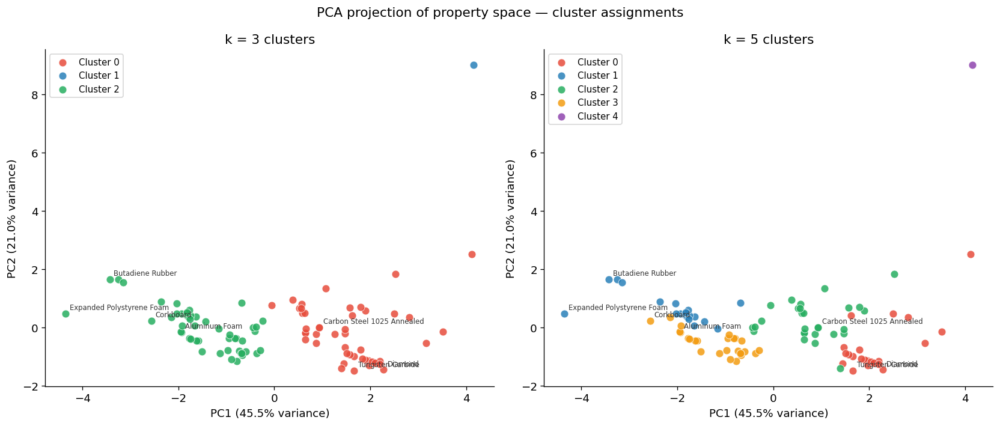

In [20]:
# ── Side-by-side PCA plots: k=3 vs k=5 ───────────────────────

COLORS_3 = ["#e74c3c", "#2980b9", "#27ae60"]
COLORS_5 = ["#e74c3c", "#2980b9", "#27ae60", "#f39c12", "#8e44ad"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, k, km_model, col, colors, title in [
    (axes[0], 3, km3, "Cluster_k3", COLORS_3, "k = 3 clusters"),
    (axes[1], 5, km5, "Cluster_k5", COLORS_5, "k = 5 clusters"),
]:
    for c in range(k):
        mask = df[col] == c
        ax.scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=colors[c], label=f"Cluster {c}",
            s=60, alpha=0.85, edgecolors="white", linewidths=0.5,
        )

    # Label a few key materials
    highlight = [
        "Corkboard (0.12 Specific Gravity)",
        "Expanded Polystyrene Foam",
        "Butadiene Rubber",
        "Diamond",
        "Tungsten Carbide",
        "Carbon Steel 1025 Annealed",
        "Aluminum Foam",
    ]
    for i, row in df.iterrows():
        if row["Material Name"] in highlight:
            ax.annotate(
                row["Material Name"].split("(")[0].strip(),
                (X_pca[i, 0], X_pca[i, 1]),
                fontsize=7, xytext=(4, 4), textcoords="offset points",
                color="#333333",
            )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9, framealpha=0.8)

plt.suptitle("PCA projection of property space — cluster assignments", fontsize=13)
plt.tight_layout()
plt.show()


#### Connecting Results to Auxetic Materials Science

It is useful to represent the data in 7-dimensional space, but in that format, it is not easily interpretable by humans. Collapsing the 7 dimensions down into 2 dimensions makes the data more comprehensible, but the resulting clusters still need to be interpreted in terms of real-world physics.

In [21]:
# ── Which cluster contains the foam / low-stiffness / cellular materials? ──
#
# These are the most relevant to auxetic applications:
# low density + cellular structure + high deformability

auxetic_candidates = [
    "Corkboard (0.12 Specific Gravity)",
    "Corkboard (0.25 Specific Gravity)",
    "Expanded Polystyrene Foam",
    "Acroyonitrile Butadiene Styrene Foam",
    "Aluminum Foam",
    "Butadiene Rubber",
    "Polysulfide Rubber",
    "Styrene Butadiene Rubber",
    "Leather",
    "Polyurethane",
    "Thermoplastic Polyurethane",
]

print("Auxetic candidate materials and their cluster assignments:\n")
print(f"{'Material':<46}  k=3 cluster   k=5 cluster")
print("─" * 68)

for mat in auxetic_candidates:
    row = df[df["Material Name"] == mat]
    if not row.empty:
        c3 = int(row["Cluster_k3"].values[0])
        c5 = int(row["Cluster_k5"].values[0])
        rho = row["Density (g/cm^3)"].values[0]
        E   = row["Elastic Modulus (GPa)"].values[0]
        print(f"{mat:<46}  Cluster {c3}       Cluster {c5}    (ρ={rho:.3f}, E={E:.4f})")


Auxetic candidate materials and their cluster assignments:

Material                                        k=3 cluster   k=5 cluster
────────────────────────────────────────────────────────────────────
Corkboard (0.12 Specific Gravity)               Cluster 2       Cluster 3    (ρ=0.120, E=0.0134)
Corkboard (0.25 Specific Gravity)               Cluster 2       Cluster 3    (ρ=0.250, E=0.0506)
Expanded Polystyrene Foam                       Cluster 2       Cluster 1    (ρ=0.020, E=0.0052)
Acroyonitrile Butadiene Styrene Foam            Cluster 2       Cluster 3    (ρ=0.840, E=1.2500)
Aluminum Foam                                   Cluster 2       Cluster 3    (ρ=0.500, E=5.0000)
Butadiene Rubber                                Cluster 2       Cluster 1    (ρ=0.925, E=0.0015)
Polysulfide Rubber                              Cluster 2       Cluster 1    (ρ=1.295, E=0.0018)
Styrene Butadiene Rubber                        Cluster 2       Cluster 1    (ρ=0.951, E=0.0060)
Leather              

### Discussion Questions

Use the tables and plots above to answer these questions in your notebook:

1. **Cluster identity**: Look at the Cluster Profile Table.
   What physical material family does each cluster represent?
   *(Hint: compare mean density and elastic modulus against your knowledge of metals, ceramics, polymers, foams.)*

2. **Auxetic candidates**: Which cluster consistently contains cork, EPS foam,
   and the rubbers? What property signature defines that cluster?

3. **Why these materials?**: Auxetic behavior emerges from geometric microarchitecture
   (re-entrant honeycombs, chiral lattices). Why would a low-density, low-modulus,
   deformable material be a better substrate for those architectures than, for example,
   tungsten carbide?

4. **k=3 vs k=5**: Did the foam/rubber cluster remain intact as you went from
   k=3 to k=5, or did it split? What does that tell you about the distinctiveness
   of that material family in property space?

5. **Poisson's ratio**: Look at the cluster means for ν in the profile table.
   Does the auxetics-candidate cluster have the lowest ν in the dataset?
   Why might that matter, even though none of these materials is intrinsically auxetic?

6. **Limits of the model**: Can k-means tell you that a material *is* auxetic?
   What additional information would you need to make that determination?

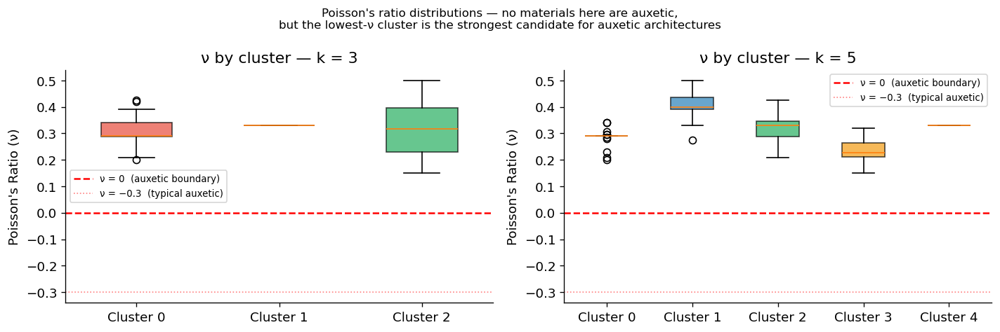

In [22]:
# ── Optional extension: Poisson's ratio distribution by cluster ─────────
#
# Auxetic materials require ν < 0. None exist in this dataset,
# but the cluster with the lowest average ν contains materials
# with the most potential to be engineered into auxetic structures.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, k, col, colors, title in [
    (axes[0], 3, "Cluster_k3", COLORS_3, "k = 3"),
    (axes[1], 5, "Cluster_k5", COLORS_5, "k = 5"),
]:
    data_by_cluster = [df[df[col] == c]["Poisson's Ratio"].dropna().values
                       for c in range(k)]
    bp = ax.boxplot(data_by_cluster, patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.axhline(0, color="red", linestyle="--", linewidth=1.5, label="ν = 0  (auxetic boundary)")
    ax.axhline(-0.3, color="red", linestyle=":", linewidth=1, alpha=0.5,
               label="ν = −0.3  (typical auxetic)")
    ax.set_xticklabels([f"Cluster {c}" for c in range(k)])
    ax.set_ylabel("Poisson's Ratio (ν)")
    ax.set_title(f"ν by cluster — {title}")
    ax.legend(fontsize=8)

plt.suptitle("Poisson's ratio distributions — no materials here are auxetic,\n"
             "but the lowest-ν cluster is the strongest candidate for auxetic architectures",
             fontsize=10)
plt.tight_layout()
plt.show()


---
#### Activity Summary

| Step | What we did | Why it matters |
|---|---|---|
| Log-transform | Applied log₁₀ to Density and Elastic Modulus | Compress multi-decade spans before scaling |
| StandardScaler | Zero-mean, unit-variance for all features | Equal weight in Euclidean distance |
| Mean imputation | Filled the handful of missing values per column | K-means cannot handle NaN |
| Elbow + Silhouette | Swept k = 2 → 8 | Principled choice of k, not guessing |
| K-means k=3 and k=5 | Single parameter change | Shows how resolution changes cluster identity |
| Profile table | Mean properties per cluster | The key to physical interpretation |
| PCA visualization | 2D projection of 7D space | Makes cluster structure visible |

**Key finding:** The foam/elastomer cluster (cork, EPS foam, rubbers, polyurethane)
is the auxetics-relevant group — not because those materials *are* auxetic,
but because their low density, low modulus, and cellular/deformable nature
makes them the best substrates for the geometric microarchitectures that *produce* auxeticity.

## Sources
1. P. H. Mott, C. M. Roland, "Limits to Poisson’s ratio in isotropic materials," *Physical Review B*, vol. 80, 132104-1–132104-4, Oct. 2009. Accessed: Jul. 7, 2026. doi: 10.1103/PhysRevB.80.132104. [Online]. Available: http://polymerphysics.net/pdf/PhysRevB_80_132104_09.pdf
2. S. Dong, H. Hu, "Sensors Based on Auxetic Materials and Structures: A Review," *Materials*, vol. 16 no. 9, 3603, May 2023. Accessed: Jul. 7, 2026. doi: 10.3390/ma16093603. [Online]. Available: https://doi.org/10.3390/ma16093603
3. M. Periyasamy, N. Srinivasan, "A review on auxetic structures: Applications, properties, classifications, finite element analysis, manufacturing methods, and selective laser melting process parameters," *Results in Engineering*, vol. 28, 107660, Dec. 2025. Accessed: Jul. 7, 2026. doi: 10.1016/j.rineng.2025.1076603. [Online]. Available: https://doi.org/10.1016/j.rineng.2025.107660
4. "Nike Free Rn Flyknit 2018 Women's Silver White Black 942839-100," https://www.walmart.com/ip/Nike-Women-s-Free-RN-Flyknit-2018-Running-Shoe-942839-101-6-B-M-US-White-Black/639384533. Accessed: Jul. 7, 2026. 
5. L. Foster, P. Peketi,T. Allen, T. Senior, O. Duncan, A. Alderson, "Application of Auxetic Foam in Sports Helmets," *Applied Sciences*, vol. 8, no. 3, 354, Mar. 2018. Accessed: Jul. 7, 2026. doi: 10.3390/app8030354. [Online]. Available: https://www.mdpi.com/2076-3417/8/3/354
6. Y. Kim, K. H. Son, J. W. Lee, "Auxetic Structures for Tissue Engineering Scaffolds and Biomedical Devices," *Materials (Basel)*, vol. 14, no. 22, 6821, Nov. 2021. Accessed: Jul. 7, 2026. doi: 10.3390/ma14226821. [Online]. Available: https://pmc.ncbi.nlm.nih.gov/articles/PMC8621588/
7. R. F. P. Junio, P. H. P. Mendonça da Silveira, L. de Mendonça Neuba,S. N. Monteiro, L. F. C. Nascimento, "Development and Applications of 3D Printing-Processed Auxetic Structures for High-Velocity Impact Protection: A Review," *Eng*, vol. 4, no. 1, 903-940, Mar. 2023. Accessed: Jul. 7, 2026. doi: 10.3390/eng4010054. [Online]. Available: https://doi.org/10.3390/eng4010054
8. E. Kavlakoglu and V. Winland, “What is k-means clustering?,” June 2024. Accessed: July 22, 2026. [Online]. Available: https://www.ibm.com/think/topics/k-means-clustering